# EDA para Forecasting de Demanda (Multivariado, horizonte 3 meses)

**Objetivo**: Analizar la serie temporal de ventas diarias (luego agregaremos a nivel mensual) para identificar tendencia, estacionalidad, relaciones entre variables y preparar los datos para modelado predictivo.

**Consideraciones clave**:
- Productos alimenticios → el overstock es crítico (pérdida total si caducan).
- Granularidad final: predicción mensual por **categoría** (o producto si los datos lo permiten).
- Horizonte: 3 meses después del último dato disponible (2024-12-11).
- Métrica de éxito: reducción del overstock (errores por exceso más penalizados que por defecto).

In [1]:
# Tratamiento de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Análisis temporal
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Configuración
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)

# Cargar datos (ajusta la ruta a tu archivo)
df = pd.read_csv('clean_data.csv', parse_dates=['fecha'])

print("Shape:", df.shape)
df.head()

Shape: (24249, 10)


,Unnamed: 0,fecha,producto,categoria,cantidad,precio_unitario,total,metodo_pago,es_outlier,cantidad_log
0,0,2023-09-30,Papas precocinadas,Congelados,1,2.3,2.3,Tarjeta crédito,False,0.693147
1,1,2024-10-31,Bolsas plásticas,Descartables,19,0.1,1.9,Tarjeta débito,True,2.995732
2,2,2024-09-14,Leche entera,Lácteos,4,1.2,4.8,Tarjeta débito,False,1.609438
3,3,2023-11-27,Papas precocinadas,Congelados,2,2.3,4.6,QR,False,1.098612
4,4,2023-12-12,Leche entera,Lácteos,1,1.2,1.2,QR,False,0.693147


In [2]:
# Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24249 entries, 0 to 24248
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       24249 non-null  int64         
 1   fecha            24249 non-null  datetime64[us]
 2   producto         24249 non-null  str           
 3   categoria        24249 non-null  str           
 4   cantidad         24249 non-null  int64         
 5   precio_unitario  24249 non-null  float64       
 6   total            24249 non-null  float64       
 7   metodo_pago      24249 non-null  str           
 8   es_outlier       24249 non-null  bool          
 9   cantidad_log     24249 non-null  float64       
dtypes: bool(1), datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 1.7 MB


In [3]:
# Resumen estadístico de variables numéricas
df.describe()

,Unnamed: 0,fecha,cantidad,precio_unitario,total,cantidad_log
count,24249.000000,24249,24249.000000,24249.000000,24249.000000,24249.000000
mean,14059.855499,2024-01-17 11:50:31.696152,2.954555,2.134296,3.741057,1.211149
min,0.000000,2023-01-03 00:00:00,1.000000,0.100000,0.100000,0.693147
25%,6968.000000,2023-08-05 00:00:00,1.000000,0.750000,1.200000,0.693147
50%,13998.000000,2024-01-15 00:00:00,2.000000,1.200000,3.200000,1.098612
75%,21109.000000,2024-06-29 00:00:00,4.000000,4.000000,4.600000,1.609438
max,28357.000000,2024-12-11 00:00:00,19.000000,5.800000,29.000000,2.995732
std,8180.699836,NaN,2.624105,1.823723,3.034492,0.539109


In [4]:
# Valores nulos por columna
df.isnull().sum()

Unnamed: 0         0
fecha              0
producto           0
categoria          0
cantidad           0
precio_unitario    0
total              0
metodo_pago        0
es_outlier         0
cantidad_log       0
dtype: int64

In [5]:
# Duplicados
print("Duplicados exactos:", df.duplicated().sum())

Duplicados exactos: 0


### Distribución de 'cantidad'

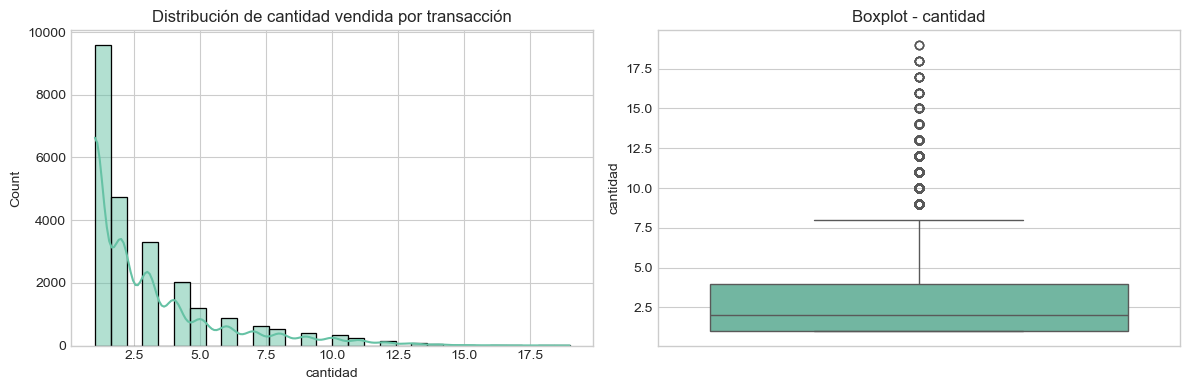

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
sns.histplot(df['cantidad'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribución de cantidad vendida por transacción')

# Boxplot
sns.boxplot(y=df['cantidad'], ax=axes[1])
axes[1].set_title('Boxplot - cantidad')

plt.tight_layout()
plt.show()

In [7]:
# Outliers potenciales (rango intercuartil)
Q1 = df['cantidad'].quantile(0.25)
Q3 = df['cantidad'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
outliers = df[df['cantidad'] > limite_superior]
print(f"Outliers por encima de {limite_superior:.1f}: {len(outliers)} transacciones")

Outliers por encima de 8.5: 1360 transacciones


## Agregamos ventas totales por mes y producto/categoría

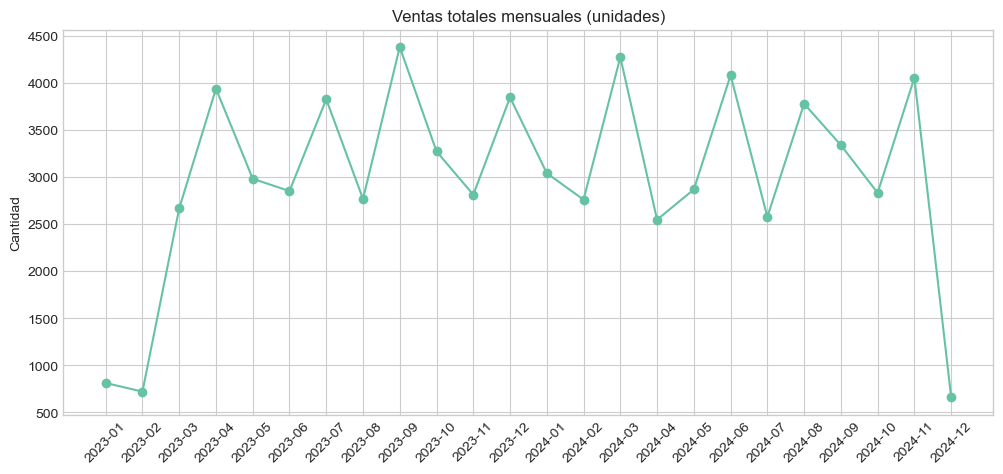

In [8]:
# Crear columna año-mes
df['anio_mes'] = df['fecha'].dt.to_period('M')

# Ventas totales por mes (todas las categorías)
ventas_mensuales = df.groupby('anio_mes')['cantidad'].sum().reset_index()
ventas_mensuales['anio_mes'] = ventas_mensuales['anio_mes'].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(ventas_mensuales['anio_mes'], ventas_mensuales['cantidad'], marker='o')
plt.xticks(rotation=45)
plt.title('Ventas totales mensuales (unidades)')
plt.ylabel('Cantidad')
plt.grid(True)
plt.show()

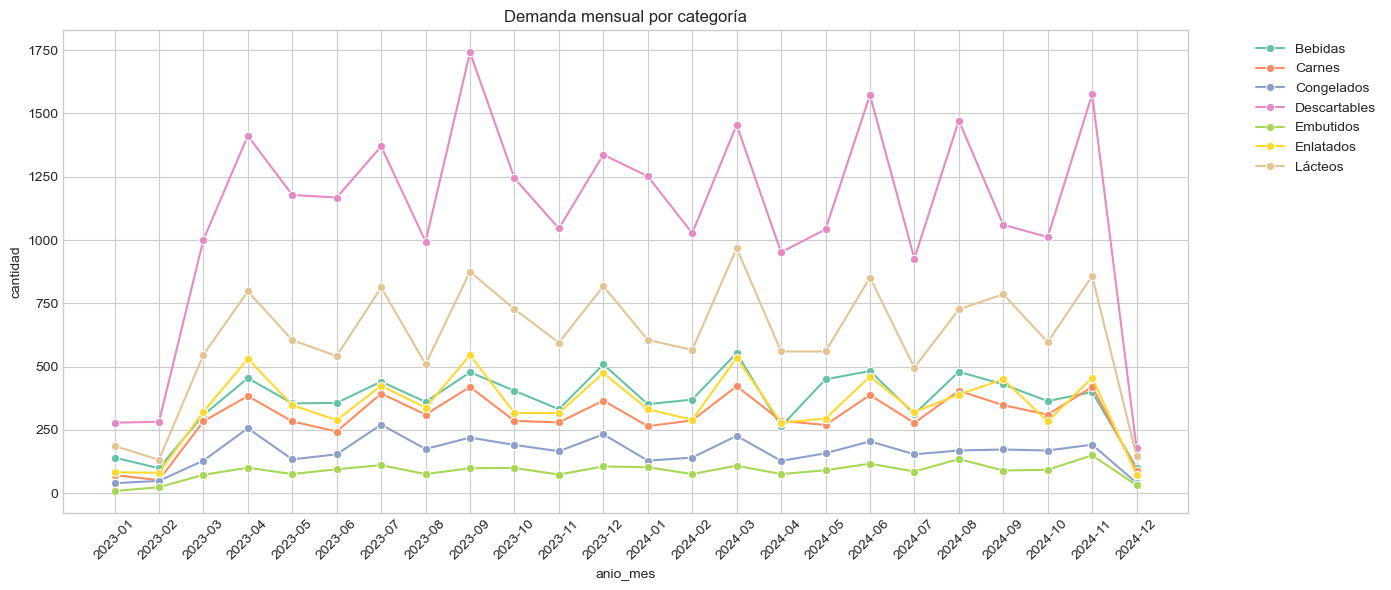

In [9]:
# Ventas mensuales por categoría
ventas_categoria_mes = df.groupby(['anio_mes', 'categoria'])['cantidad'].sum().reset_index()
ventas_categoria_mes['anio_mes'] = ventas_categoria_mes['anio_mes'].astype(str)

# Gráfico de líneas por categoría
plt.figure(figsize=(14, 6))
sns.lineplot(data=ventas_categoria_mes, x='anio_mes', y='cantidad', hue='categoria', marker='o')
plt.xticks(rotation=45)
plt.title('Demanda mensual por categoría')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Descomposición estacional para una categoría representativa

Seleccionamos una categoría con suficiente historia para ver tendencia y estacionalidad.

Categoría con más datos: Bebidas


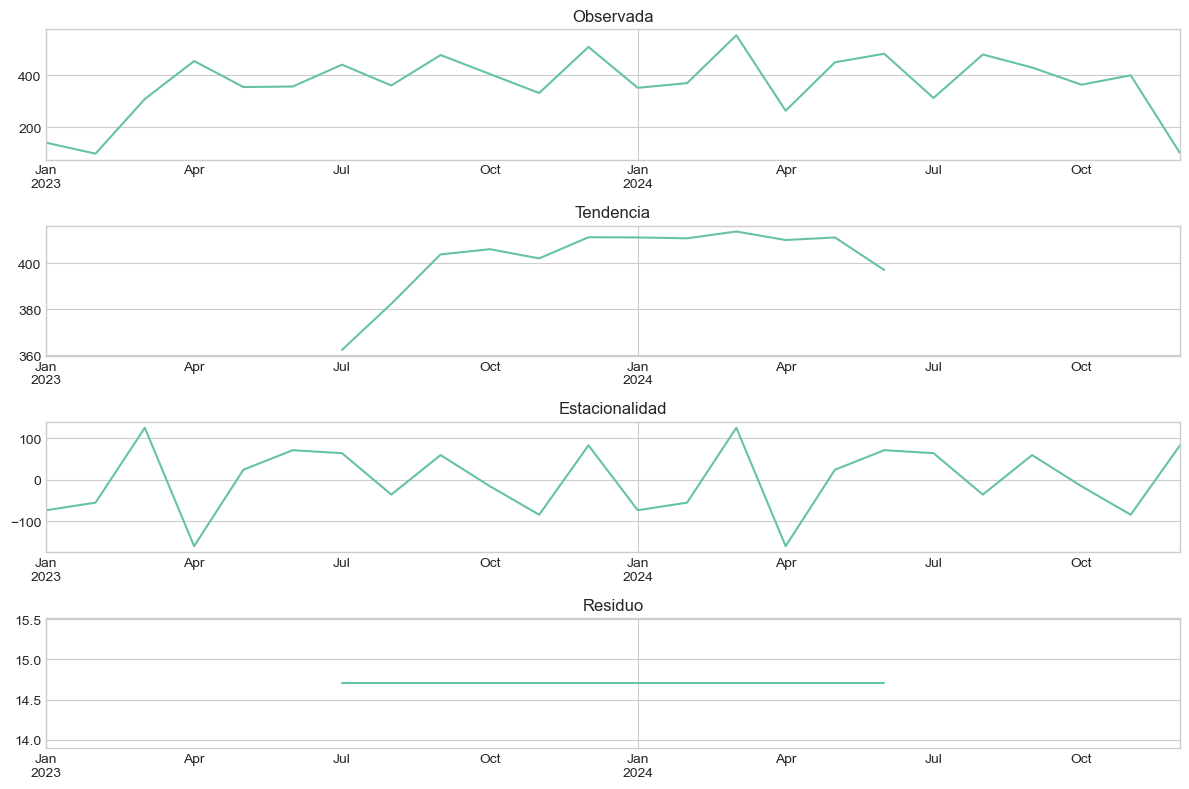

In [10]:
# Elegir categoría (ej. 'Lácteos' o la que tenga más datos)
cat_ejemplo = ventas_categoria_mes['categoria'].value_counts().idxmax()
print("Categoría con más datos:", cat_ejemplo)

serie = ventas_categoria_mes[ventas_categoria_mes['categoria'] == cat_ejemplo].copy()
serie = serie.set_index('anio_mes')['cantidad'].astype(float)
serie.index = pd.date_range(start='2023-01', periods=len(serie), freq='ME')

# Descomposición (modelo aditivo)
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(serie, model='additive', period=12)  # estacionalidad anual

fig, axes = plt.subplots(4, 1, figsize=(12, 8))
decomp.observed.plot(ax=axes[0], title='Observada')
decomp.trend.plot(ax=axes[1], title='Tendencia')
decomp.seasonal.plot(ax=axes[2], title='Estacionalidad')
decomp.resid.plot(ax=axes[3], title='Residuo')
plt.tight_layout()
plt.show()

## Relación entre precio_unitario y cantidad (demanda sensible al precio)

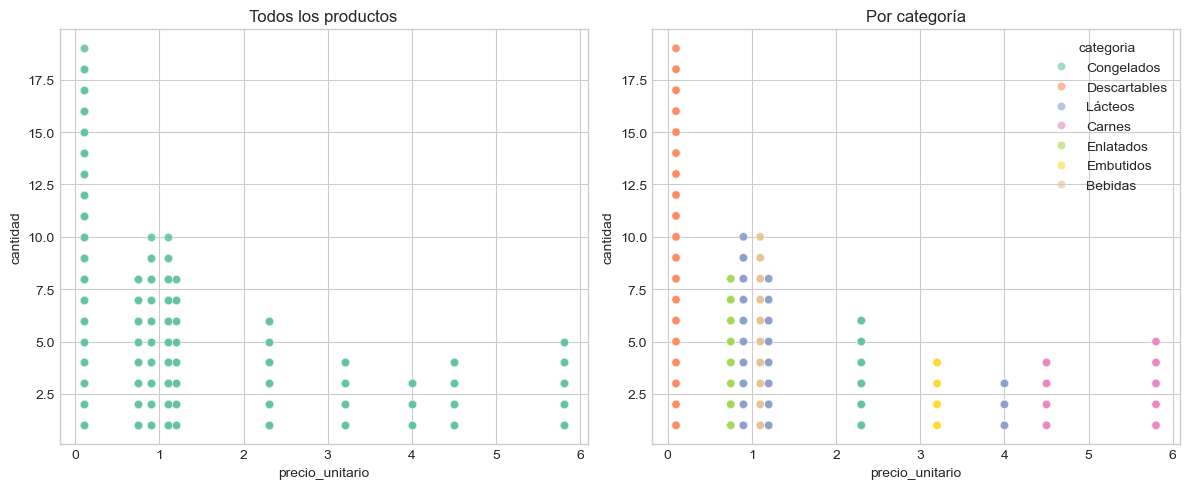

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter general
sns.scatterplot(data=df, x='precio_unitario', y='cantidad', alpha=0.5, ax=axes[0])
axes[0].set_title('Todos los productos')

# Scatter por categoría
sns.scatterplot(data=df, x='precio_unitario', y='cantidad', hue='categoria', alpha=0.6, ax=axes[1])
axes[1].set_title('Por categoría')
plt.tight_layout()
plt.show()

In [12]:
# Correlación por categoría
corr_por_cat = df.groupby('categoria')[['precio_unitario', 'cantidad']].corr().iloc[0::2, -1]
print(corr_por_cat)

categoria                    
Bebidas       precio_unitario         NaN
Carnes        precio_unitario   -0.011307
Congelados    precio_unitario         NaN
Descartables  precio_unitario         NaN
Embutidos     precio_unitario         NaN
Enlatados     precio_unitario         NaN
Lácteos       precio_unitario   -0.322584
Name: cantidad, dtype: float64


## Método de pago y su relación con el volumen de compra

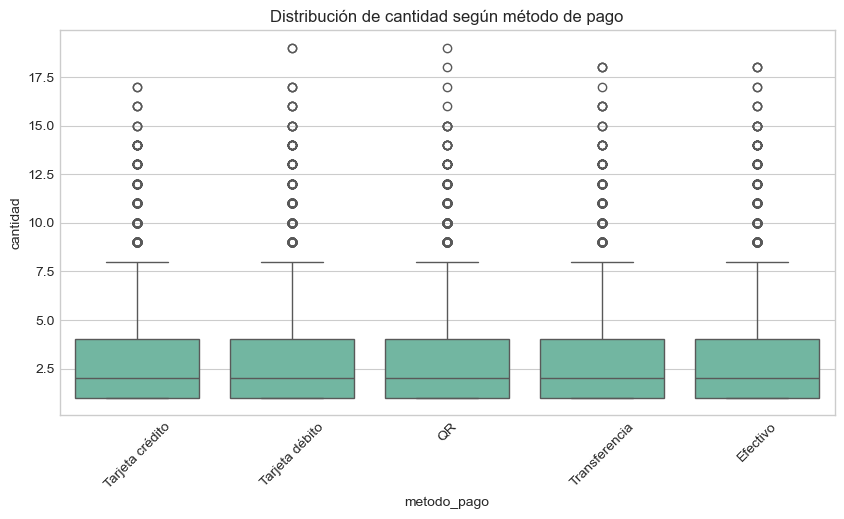

In [13]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='metodo_pago', y='cantidad')
plt.title('Distribución de cantidad según método de pago')
plt.xticks(rotation=45)
plt.show()

In [14]:
# ANOVA rápido (si quieres significación estadística)
from scipy.stats import f_oneway
grupos = [df[df['metodo_pago'] == p]['cantidad'] for p in df['metodo_pago'].unique()]
stat, p = f_oneway(*grupos)
print(f"p-valor ANOVA: {p:.4f} -> {'diferencias significativas' if p < 0.05 else 'no significativas'}")

p-valor ANOVA: 0.4392 -> no significativas


## Análisis de la transformación logarítmica (cantidad_log)

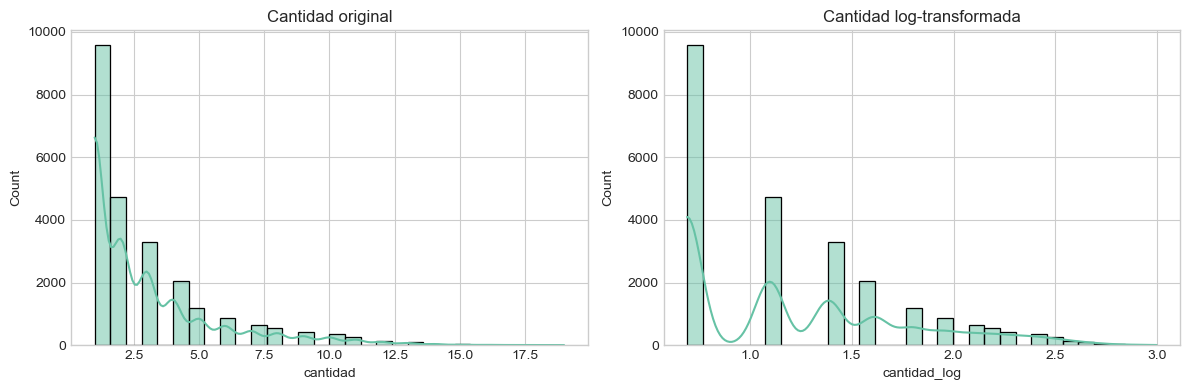

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['cantidad'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Cantidad original')
sns.histplot(df['cantidad_log'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Cantidad log-transformada')
plt.tight_layout()
plt.show()

## Evaluación de overstock (simulación de demanda vs oferta)

Según el contexto, en el Mes 1 hubo un excedente de 1246 unidades. 
Vamos a analizar la variabilidad de la demanda para identificar productos/categorías con mayor riesgo de overstock.

In [16]:
# Coeficiente de variación por producto (riesgo relativo)
riesgo = df.groupby('producto').agg(
    media=('cantidad', 'mean'),
    std=('cantidad', 'std')
)
riesgo['cv'] = riesgo['std'] / riesgo['media']
riesgo_sorted = riesgo.sort_values('cv', ascending=False)
print("Top 10 productos con mayor variabilidad (riesgo de overstock):")
riesgo_sorted.head(10)

Top 10 productos con mayor variabilidad (riesgo de overstock):


,media,std,cv
producto,,,
Leche entera,2.140159,1.251094,0.584580
Papas precocinadas,2.087119,1.200891,0.575382
Yogurt natural,3.037138,1.678126,0.552535
Pasta de Tomate,2.992372,1.627663,0.543937
Refresco 2L,3.004437,1.631349,0.542980
Carne molida,1.362461,0.688998,0.505701
Pollo entero,1.378242,0.692722,0.502613
Jamón de pavo,1.361399,0.662063,0.486311
Helado familiar,1.328877,0.600063,0.451556


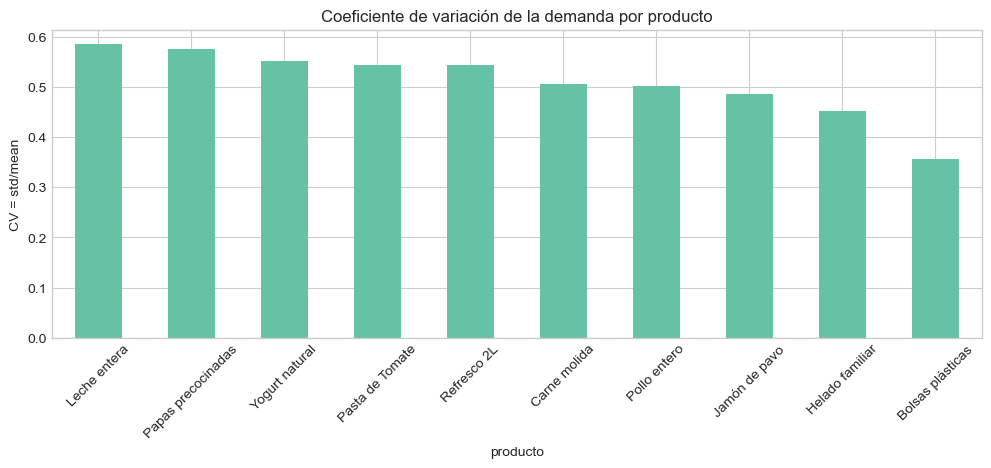

In [17]:
# Visualización
plt.figure(figsize=(12, 4))
riesgo_sorted.head(15)['cv'].plot(kind='bar')
plt.title('Coeficiente de variación de la demanda por producto')
plt.ylabel('CV = std/mean')
plt.xticks(rotation=45)
plt.show()

## Autocorrelación temporal (para forecasting)

Evaluamos si la demanda mensual tiene memoria (autocorrelación) útil para forecasting.

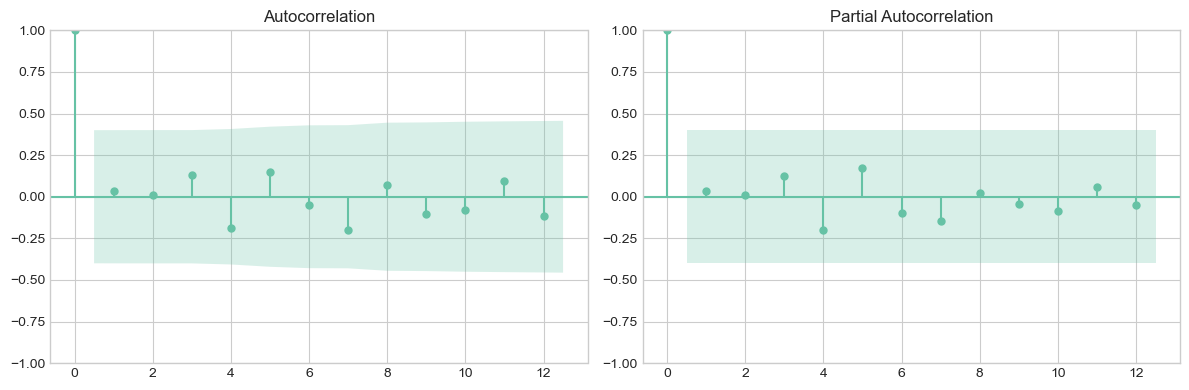

In [19]:
# Serie mensual total
serie_total = ventas_mensuales.set_index('anio_mes')['cantidad'].astype(float)
serie_total.index = pd.date_range(start='2023-01', periods=len(serie_total), freq='ME')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(serie_total, lags=12, ax=axes[0])
plot_pacf(serie_total, lags=12, ax=axes[1])
plt.tight_layout()
plt.show()

## Conclusiones del EDA y acciones para modelado

### Conclusiones clave

1. **Estacionalidad**: Se observa patrón recurrente (ej. picos en ciertos meses) → usar modelos que capturen estacionalidad (SARIMA, Prophet, XGBoost con features cíclicas).

2. **Overstock crítico**: Productos con alta variabilidad (CV > 1) requieren forecast conservador (sesgado a la baja) o bandas de predicción.

3. **Relaciones**: Precio unitario muestra correlación negativa débil en algunas categorías → considerar como covariable.

4. **Método de pago**: Diferencias significativas en volumen → puede ser útil como feature.

5. **Transformación log**: Mejora simetría, útil si usamos modelos que asumen normalidad.

### Próximos pasos para el forecasting

- Agregar datos a nivel **mensual por categoría** (o producto si hay suficiente historia).
- Crear features: rezagos, medias móviles, día de la semana (si se baja a diario), mes, trimestre.
- Elegir métrica asimétrica: **MAPE ponderado con penalización extra por overestimation**.
- Dividir train/val/test respetando orden temporal (ej. train hasta 2024-09, val 2024-10 a 12, test 3 meses).
- Probar modelos: SARIMA, Elastic Net con features temporales, LightGBM, o Prophet.
- Evaluar con foco en error de exceso (overstock) vs defecto.

## Exportar resumen para modelado (opcional)

In [20]:
# Guardar datos agregados mensuales por categoría para modelado
ventas_categoria_mes.to_csv('ventas_mensuales_por_categoria.csv', index=False)
print("Archivo guardado para la fase de modelado.")

Archivo guardado para la fase de modelado.
